In [1]:
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_num_cpu_devices', 4)
print(jax.local_device_count(),flush=True)
print(jax.devices(),flush=True)
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

4
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]


In [15]:
norm=TwoSlopeNorm(vmin=0, vcenter=1, vmax=10)
cmap=plt.get_cmap('coolwarm')
def plot(real,imag,rho):
    plt.figure(figsize=(5,5))
    plt.xlabel("real")
    plt.ylabel("imag")
    plt.contour(real,imag,jnp.abs(rho),jnp.logspace(-1,1,21,endpoint=True,base=10), norm=norm, cmap=cmap)
    plt.title("|ρ|")
    cbar=plt.colorbar()
    cbar.set_label("|ρ|")
    cbar.set_ticks([0.1, 1, 10])
    plt.show()

In [3]:
real_coordinate=jnp.linspace(-2,2,2001)
imag_coordinate=jnp.linspace(-2,2,2001)
real,imag=jnp.meshgrid(real_coordinate,imag_coordinate,indexing='ij')
z=real+1j*imag

(a)

$$\rho(z)=1+z/det=(1/12\ z^2+1/2\ z+1)/(1/12\ z^2-1/2\ z+1)$$



In [16]:
rho=(z**2/12+z/2+1)/(z**2/12-z/2+1)

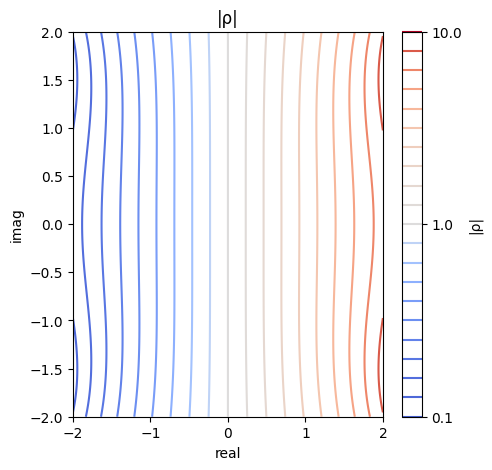

In [17]:
plot(real,imag,rho)

(b)

Second order
$$\rho^2-2z\rho-1=0$$

In [6]:
def get_max_rho_2(z):
    coeffs=jnp.array([1,-2*z,-1],dtype=jnp.complex128)
    roots=jnp.roots(coeffs,strip_zeros=False)
    return jnp.nanmax(jnp.abs(roots))
get_max_rho_2=jax.jit(jax.vmap(jax.vmap(get_max_rho_2)))
rho_2=get_max_rho_2(z)
print(f'Min: {jnp.nanmin(rho_2)}, Max: {jnp.nanmax(rho_2)}')

Min: 0.9999999999999997, Max: 5.665099857880397


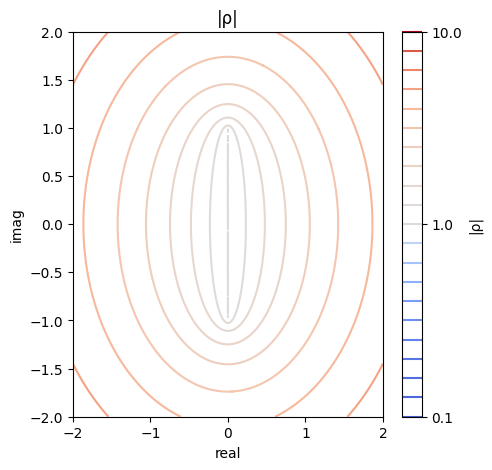

In [18]:
plot(real,imag,get_max_rho_2(z))

(b)

Second order
$$\rho^3+\left(\frac{3}{2}-3z\right)\rho^2-3\rho+\frac{1}{2}=0$$

In [8]:
def get_max_rho_3(z):
    coeffs=jnp.array([1,1.5-3*z,-3,0.5],dtype=jnp.complex128)
    roots=jnp.roots(coeffs,strip_zeros=False)
    return jnp.nanmax(jnp.abs(roots))
get_max_rho_3=jax.jit(jax.vmap(jax.vmap(get_max_rho_3)))
rho_3=get_max_rho_3(z)
print(f'Min: {jnp.nanmin(rho_3)}, Max: {jnp.nanmax(rho_3)}')

Min: 1.7325064364610847, Max: 9.68493079916807


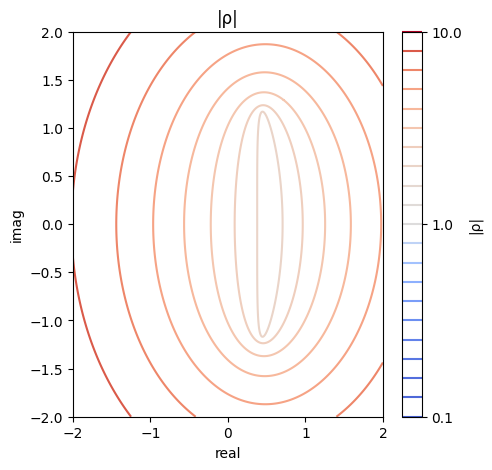

In [19]:
plot(real,imag,rho_3)